## SH ESTRUTURAS METÁLICAS
### OBRA: ADMINISTRATIVO - PERTO PERIFÉRICOS S.A.
#### AUTOR: ENG. RICHARD GOSSLER

### Metodologia de Compatibilização Geométrica e Otimização da Fachada

A análise do levantamento topográfico e a definição das soluções de montagem dos suportes de alumínio (pele de vidro) baseiam-se em uma modelagem matemática dividida em três etapas principais:

#### 1. Retificação do Sistema Geométrico (Translação e Rotação)
Para determinar o desvio ortogonal real de cada ponto em relação ao plano projetado da fachada, estabelece-se uma linha de base utilizando o primeiro e o último ponto do pavimento térreo. O ângulo de inclinação global da estrutura teórica é calculado por:

$$ \theta = \arctan\left(\frac{Y_{fim} - Y_{ini}}{X_{fim} - X_{ini}}\right) $$

A partir deste ângulo, aplica-se a matriz de rotação inversa para alinhar a fachada teórica com o eixo X. O desvio inicial em milímetros ($D_{ini}$) de qualquer ponto $(X, Y)$ é dado por:

$$ D_{ini} = \left( X \cdot \sin(-\theta) + Y \cdot \cos(-\theta) \right) \cdot 1000 $$

#### 2. Modelagem da Função de Custo de Montagem
O furo oblongo padrão do suporte permite uma tolerância de $\pm 15$ mm. Adicionando calços de 10 mm e 5 mm, a zona de absorção estende-se de forma assimétrica. Seja $\delta$ o desvio final após a aplicação de um deslocamento global (offset). A função de custo $C(\delta)$ penaliza soluções financeiramente ou operacionalmente mais caras (como fabricação de suportes sob medida):

$$ C(\delta) = \begin{cases} 
0, & \text{se } -15 \le \delta \le 15 \text{ (Oblongo padrão)} \\ 
2, & \text{se } -25 \le \delta < -15 \text{ (Oblongo + Calço 10mm)} \\ 
3, & \text{se } -30 \le \delta < -25 \text{ (Oblongo + Calços 10mm e 5mm)} \\ 
5, & \text{se } 15 < \delta \le 30 \text{ (Suporte Especial Recuado)} \\ 
10, & \text{se } -45 \le \delta < -30 \text{ (Suporte Especial Avançado + Calços)} \\ 
1000, & \text{caso contrário (Extrapolado / Inviável)} 
\end{cases} $$

#### 3. Otimização do Deslocamento Global (Offset)
Para minimizar o uso de calços e a necessidade de fabricação de peças especiais em toda a obra, o algoritmo realiza uma busca paramétrica (força bruta vetorizada) testando deslocamentos globais teóricos ($O$) no intervalo de $-40$ mm a $40$ mm, com passo de $0,1$ mm.

O objetivo é encontrar o offset $O$ que minimize o custo total de montagem para todos os $n$ pontos da fachada:

$$ \min_{O} \sum_{i=1}^{n} C(D_{ini, i} - O) $$

Após a otimização, o desvio final adotado para a execução é:

$$ D_{final} = D_{ini} - O_{ideal} $$

In [1]:
import pandas as pd
import numpy as np
import io

# 1. Dados Brutos (Cole seus dados brutos aqui na variável dados_brutos)
dados_brutos = """X	Y	Z
0	0	0
-0,8452	0,8339	-0,0101
-1,6761	1,6721	-0,0032
-2,5216	2,5224	0,0002
-3,3731	3,3814	0,0099
-4,214	4,2298	0,011
-5,0628	5,0812	0,0189
-5,9139	5,927	0,0159
-6,7592	6,7694	0,0056
-7,603	7,6048	0,0109
-8,459	8,4538	0,0047
-9,3067	9,3014	0,0076
-10,1509	10,151	0,0069
-11,003	11,0008	0,0062
-11,8448	11,8531	-0,0019
-12,6931	12,7045	0,0082
-13,535	13,5517	0,0038
-14,3787	14,3988	0,0023
-15,2311	15,2503	0,0074
-16,082	16,0906	0,0131
-16,9366	16,935	0,0167
-17,7922	17,7833	0,0067
-18,6405	18,6345	0,011
-19,4798	19,4789	0,0086
-20,325	20,3293	0,0103
-21,1666	21,1723	0,0171
-22,0125	22,018	0,0096
-22,8755	22,8685	0,0136
-23,7313	23,7158	0,0069
-24,573	24,5554	0,0042
-25,4246	25,4081	0,0019
-26,2733	26,2539	0,0041
-27,115	27,1026	-0,0043
-27,9619	27,9463	0,0043
-28,8167	28,7937	0,0021
-29,6741	29,6407	0,0103
-30,5221	30,4845	0,0156
-31,3619	31,331	0,0186
-32,2133	32,1739	0,0128
-33,0622	33,0279	-0,0008
-33,9123	33,8788	0,0067
-34,7449	34,7082	0,0086
0,0064	-0,0313	3,732
-0,8341	0,8077	3,7367
-1,6948	1,669	3,7385
-2,541	2,5186	3,7324
-3,3847	3,3698	3,7499
-4,228	4,2189	3,7555
-5,0694	5,0689	3,7717
-5,9131	5,9156	3,7683
-6,7533	6,7576	3,771
-7,6024	7,604	3,7695
-8,4607	8,4568	3,7691
-9,3126	9,3016	3,7531
-10,1635	10,1456	3,7591
-11,0049	10,9811	3,7484
-11,8649	11,8385	3,7549
-12,7159	12,6904	3,7594
-13,5618	13,5384	3,7612
-14,4117	14,3929	3,7603
-15,2481	15,2352	3,7618
-16,0933	16,084	3,7756
-16,9387	16,9251	3,7673
-17,7868	17,7701	3,7716
-18,6449	18,6333	3,7778
-19,4758	19,4742	3,7609
-20,3209	20,3263	3,7654
-21,1809	21,1824	3,7643
-22,0204	22,0288	3,7643
-22,8658	22,873	3,7657
-23,7219	23,7272	3,7608
-24,5699	24,5681	3,751
-25,4259	25,4141	3,7476
-26,2648	26,2485	3,7535
-27,1318	27,0995	3,7484
-27,9833	27,9476	3,7503
-28,833	28,7921	3,7604
-29,6875	29,6415	3,7521
-30,536	30,4887	3,7669
-31,386	31,3306	3,7691
-32,2242	32,1806	3,7579
-33,064	33,0276	3,7669
-33,9147	33,8837	3,7626
-34,7693	34,729	3,7616
-0,007	-0,0422	8,0018
-0,8517	0,8011	7,9861
-1,7062	1,6644	7,9943
-2,5469	2,5145	7,9908
-3,3929	3,3697	8,0067
-4,2275	4,2165	8,0146
-5,0703	5,0731	7,9985
-5,9172	5,9208	8,0236
-6,7581	6,7725	8,026
-7,6043	7,6153	8,0272
-8,4601	8,4535	8,0394
-9,3136	9,2899	8,0195
-10,1626	10,1309	8,0222
-11,0046	10,9791	8,0098
-11,8705	11,8363	8,0274
-12,7167	12,681	8,0209
-13,5638	13,5279	8,0262
-14,4122	14,3739	8,0139
-15,2636	15,2304	8,0213
-16,0974	16,074	8,0229
-16,9465	16,9322	8,0189
-17,7879	17,7813	8,0277
-18,6333	18,6312	8,0255
-19,4804	19,4847	8,0271
-20,3249	20,3336	8,0395
-21,1786	21,1839	8,0396
-22,0254	22,038	8,0281
-22,8727	22,877	8,0172
-23,7367	23,7252	8,0122
-24,5835	24,565	8,0138
-25,437	25,4115	8,0167
-26,2781	26,2592	8,0296
-27,1392	27,0978	8,0259
-27,9972	27,9455	8,0123
-28,845	28,7902	8,0207
-29,6952	29,6361	8,0208
-30,547	30,4889	8,0353
-31,39	31,3312	8,0312
-32,2418	32,1885	8,0291
-33,0935	33,0416	8,027
-33,9335	33,8865	8,0262
-34,7847	34,7354	8,0114"""

df = pd.read_csv(io.StringIO(dados_brutos), sep='\t', decimal=',')

# 2. Definição de Pavimentos e Prumadas
def classificar_pavimento(z):
    if z < 1.5: return 1
    elif z < 5.0: return 2
    else: return 3
    
df['Pavimento'] = df['Z'].apply(classificar_pavimento)
df['Prumada'] = df.groupby('Pavimento')['X'].rank(ascending=False, method='first').astype(int)
df['Rotulo'] = 'p' + df['Prumada'].astype(str).str.zfill(2) + '_pav' + df['Pavimento'].astype(str)
df = df.sort_values(by=['Prumada', 'Pavimento']).reset_index(drop=True)

# 3. Retificação do Sistema Geométrico (MÉTODO BLINDADO)
df_base = df[df['Pavimento'] == 1].sort_values(by='X', ascending=False).reset_index(drop=True)
x_ini, y_ini = df_base.iloc[0][['X', 'Y']].values
x_fim, y_fim = df_base.iloc[-1][['X', 'Y']].values
theta = np.arctan2(y_fim - y_ini, x_fim - x_ini)

df['Desvio_Y_Inicial_mm'] = (df['X'] * np.sin(-theta) + df['Y'] * np.cos(-theta)) * 1000

media_desvio = df['Desvio_Y_Inicial_mm'].mean()
tendencia = "RECUAR FURO OBLONGO (Estrutura estufada)" if media_desvio > 0 else "AVANÇAR FURO OBLONGO (Estrutura recuada)"

# 4. Otimizador de Deslocamento (VETORIZADO PARA PERFORMANCE EXTREMA)
def simular_deslocamento(offset):
    desv = df['Desvio_Y_Inicial_mm'].values - offset
    
    condicoes = [
        (desv >= -15) & (desv <= 15),
        (desv >= -25) & (desv < -15),
        (desv >= -30) & (desv < -25),
        (desv > 15) & (desv <= 30),
        (desv >= -45) & (desv < -30)
    ]
    pesos = [0, 2, 3, 5, 10]
    
    # Aplica os pesos conforme as condições, e 1000 se não cair em nenhuma (Extrapolado)
    custos = np.select(condicoes, pesos, default=1000)
    return custos.sum()

menor_total = 999999
offset_ideal = 0

# Varre os offsets. Com a vetorização, esse laço roda em uma fração de milissegundo.
for off in np.arange(-40, 40, 0.1):
    c = simular_deslocamento(off)
    if c < menor_total:
        menor_total = c
        offset_ideal = off
        
# 5. Categorização Final
df['Desvio_Y_mm'] = df['Desvio_Y_Inicial_mm'] - offset_ideal

def categorizar_solucao(d):
    if -15 <= d <= 15:
        return "PADRÃO (Sem calço)"
    elif -25 <= d < -15:
        return "PADRÃO c/ Calço 10 mm"
    elif -30 <= d < -25:
        return "PADRÃO c/ Calços 15 mm"
    elif 15 < d <= 30:
        return f"ESPECIAL (Recuar furo oblongo {(d - 15):.1f} mm)"
    elif -45 <= d < -30:
        return f"ESPECIAL (Avançar furo oblongo {(abs(d) - 30):.1f} mm) + Calços 15mm"
    elif d > 30:
        return f"⚠️ EXTRAPOLADO (Faltam {(d - 30):.1f} mm p/ trás)"
    else:
        return f"⚠️ EXTRAPOLADO (Faltam {(abs(d) - 45):.1f} mm p/ frente)"

df['Solucao_Montagem'] = df['Desvio_Y_mm'].apply(categorizar_solucao)

# Resumo Estatístico Final
total_especiais = df['Solucao_Montagem'].str.contains('ESPECIAL').sum()
total_calcos = df['Solucao_Montagem'].str.contains('PADRÃO c/ Calço').sum()
total_padrao = df['Solucao_Montagem'].str.contains(r'^PADRÃO \(Sem calço\)', regex=True).sum()
total_extrapolado = df['Solucao_Montagem'].str.contains('EXTRAPOLADO').sum()

print(f"==================================================")
print(f"      RELATÓRIO DE COMPATIBILIZAÇÃO OTIMIZADO     ")
print(f"==================================================")
print(f" -> Tendência da Obra (Dados Brutos): {media_desvio:.1f} mm ({tendencia})")
print(f" -> Offset aplicado na Fachada: {offset_ideal:.1f} mm")
print(f" -> Total de Pontos Analisados: {len(df)}")
print(f"    - Encaixe Padrão (só rasgo): {total_padrao} un.")
print(f"    - Suportes Padrão c/ Calços: {total_calcos} un.")
print(f"    - SUPORTES ESPECIAIS (Max ±15mm extra): {total_especiais} un.")
if total_extrapolado > 0:
    print(f"    - ⚠️ PONTOS EXTRAPOLADOS (>30mm): {total_extrapolado} un.")
else:
    print(f"    - ⚠️ PONTOS EXTRAPOLADOS: 0 un. (Otimização 100% bem sucedida!)")
print(f"==================================================\n")

# Configuração para imprimir todas as linhas na tabela geral
pd.set_option('display.max_rows', None)

print("==== TABELA GERAL DE COMPATIBILIZAÇÃO (TODAS AS PRUMADAS) ====\n")
df_print = df[['Rotulo', 'X', 'Z', 'Desvio_Y_Inicial_mm', 'Desvio_Y_mm', 'Solucao_Montagem']].copy()
df_print = df_print.round({'X': 3, 'Z': 3, 'Desvio_Y_Inicial_mm': 1, 'Desvio_Y_mm': 1})
print(df_print.to_string(index=False))

      RELATÓRIO DE COMPATIBILIZAÇÃO OTIMIZADO     
 -> Tendência da Obra (Dados Brutos): -1.5 mm (AVANÇAR FURO OBLONGO (Estrutura recuada))
 -> Offset aplicado na Fachada: 5.2 mm
 -> Total de Pontos Analisados: 126
    - Encaixe Padrão (só rasgo): 88 un.
    - Suportes Padrão c/ Calços: 31 un.
    - SUPORTES ESPECIAIS (Max ±15mm extra): 7 un.
    - ⚠️ PONTOS EXTRAPOLADOS: 0 un. (Otimização 100% bem sucedida!)

==== TABELA GERAL DE COMPATIBILIZAÇÃO (TODAS AS PRUMADAS) ====

  Rotulo       X      Z  Desvio_Y_Inicial_mm  Desvio_Y_mm                                     Solucao_Montagem
p01_pav1   0.000  0.000                 -0.0         -5.2                                   PADRÃO (Sem calço)
p01_pav2   0.006  3.732                 17.6         12.4                                   PADRÃO (Sem calço)
p01_pav3  -0.007  8.002                 34.8         29.6               ESPECIAL (Recuar furo oblongo 14.6 mm)
p02_pav1  -0.845 -0.010                  7.4          2.2                     

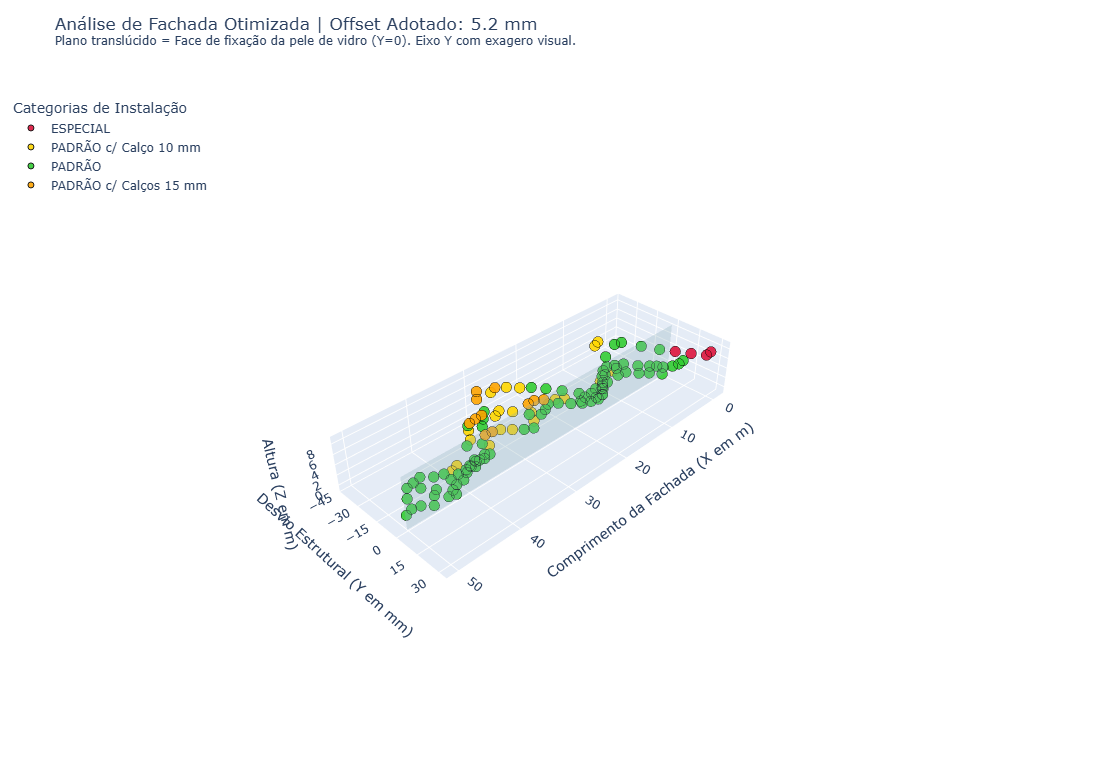

      RELATÓRIO DE COMPATIBILIZAÇÃO OTIMIZADO     
 -> Tendência Inicial: -1.5 mm (AVANÇAR FURO (Estrutura recuada))
 -> Offset aplicado: 5.2 mm

==== LISTA 1: FABRICAÇÃO DE SUPORTES ESPECIAIS ====

  Rotulo     X   Z  Desvio_Y_mm                                     Solucao_Montagem
p01_pav3  -0.0 8.0         29.6               ESPECIAL (Recuar furo oblongo 14.6 mm)
p02_pav3  -0.9 8.0         30.0               ESPECIAL (Recuar furo oblongo 15.0 mm)
p03_pav3  -1.7 8.0         23.1                ESPECIAL (Recuar furo oblongo 8.1 mm)
p04_pav3  -2.5 8.0         15.8                ESPECIAL (Recuar furo oblongo 0.8 mm)
p18_pav1 -14.4 0.0        -30.2 ESPECIAL (Avançar furo oblongo 0.2 mm) + Calços 15mm
p19_pav1 -15.2 0.0        -30.2 ESPECIAL (Avançar furo oblongo 0.2 mm) + Calços 15mm
p27_pav3 -22.0 8.0        -30.6 ESPECIAL (Avançar furo oblongo 0.6 mm) + Calços 15mm


==== LISTA 2: PONTOS COM CALÇO DE 10 mm ====

  Rotulo     X    Z  Desvio_Y_mm      Solucao_Montagem
p06_pav1  -4.2  0.

In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import io

# ==============================================================================
# 1. DADOS BRUTOS
# ==============================================================================
dados_brutos = """X	Y	Z
0	0	0
-0,8452	0,8339	-0,0101
-1,6761	1,6721	-0,0032
-2,5216	2,5224	0,0002
-3,3731	3,3814	0,0099
-4,214	4,2298	0,011
-5,0628	5,0812	0,0189
-5,9139	5,927	0,0159
-6,7592	6,7694	0,0056
-7,603	7,6048	0,0109
-8,459	8,4538	0,0047
-9,3067	9,3014	0,0076
-10,1509	10,151	0,0069
-11,003	11,0008	0,0062
-11,8448	11,8531	-0,0019
-12,6931	12,7045	0,0082
-13,535	13,5517	0,0038
-14,3787	14,3988	0,0023
-15,2311	15,2503	0,0074
-16,082	16,0906	0,0131
-16,9366	16,935	0,0167
-17,7922	17,7833	0,0067
-18,6405	18,6345	0,011
-19,4798	19,4789	0,0086
-20,325	20,3293	0,0103
-21,1666	21,1723	0,0171
-22,0125	22,018	0,0096
-22,8755	22,8685	0,0136
-23,7313	23,7158	0,0069
-24,573	24,5554	0,0042
-25,4246	25,4081	0,0019
-26,2733	26,2539	0,0041
-27,115	27,1026	-0,0043
-27,9619	27,9463	0,0043
-28,8167	28,7937	0,0021
-29,6741	29,6407	0,0103
-30,5221	30,4845	0,0156
-31,3619	31,331	0,0186
-32,2133	32,1739	0,0128
-33,0622	33,0279	-0,0008
-33,9123	33,8788	0,0067
-34,7449	34,7082	0,0086
0,0064	-0,0313	3,732
-0,8341	0,8077	3,7367
-1,6948	1,669	3,7385
-2,541	2,5186	3,7324
-3,3847	3,3698	3,7499
-4,228	4,2189	3,7555
-5,0694	5,0689	3,7717
-5,9131	5,9156	3,7683
-6,7533	6,7576	3,771
-7,6024	7,604	3,7695
-8,4607	8,4568	3,7691
-9,3126	9,3016	3,7531
-10,1635	10,1456	3,7591
-11,0049	10,9811	3,7484
-11,8649	11,8385	3,7549
-12,7159	12,6904	3,7594
-13,5618	13,5384	3,7612
-14,4117	14,3929	3,7603
-15,2481	15,2352	3,7618
-16,0933	16,084	3,7756
-16,9387	16,9251	3,7673
-17,7868	17,7701	3,7716
-18,6449	18,6333	3,7778
-19,4758	19,4742	3,7609
-20,3209	20,3263	3,7654
-21,1809	21,1824	3,7643
-22,0204	22,0288	3,7643
-22,8658	22,873	3,7657
-23,7219	23,7272	3,7608
-24,5699	24,5681	3,751
-25,4259	25,4141	3,7476
-26,2648	26,2485	3,7535
-27,1318	27,0995	3,7484
-27,9833	27,9476	3,7503
-28,833	28,7921	3,7604
-29,6875	29,6415	3,7521
-30,536	30,4887	3,7669
-31,386	31,3306	3,7691
-32,2242	32,1806	3,7579
-33,064	33,0276	3,7669
-33,9147	33,8837	3,7626
-34,7693	34,729	3,7616
-0,007	-0,0422	8,0018
-0,8517	0,8011	7,9861
-1,7062	1,6644	7,9943
-2,5469	2,5145	7,9908
-3,3929	3,3697	8,0067
-4,2275	4,2165	8,0146
-5,0703	5,0731	7,9985
-5,9172	5,9208	8,0236
-6,7581	6,7725	8,026
-7,6043	7,6153	8,0272
-8,4601	8,4535	8,0394
-9,3136	9,2899	8,0195
-10,1626	10,1309	8,0222
-11,0046	10,9791	8,0098
-11,8705	11,8363	8,0274
-12,7167	12,681	8,0209
-13,5638	13,5279	8,0262
-14,4122	14,3739	8,0139
-15,2636	15,2304	8,0213
-16,0974	16,074	8,0229
-16,9465	16,9322	8,0189
-17,7879	17,7813	8,0277
-18,6333	18,6312	8,0255
-19,4804	19,4847	8,0271
-20,3249	20,3336	8,0395
-21,1786	21,1839	8,0396
-22,0254	22,038	8,0281
-22,8727	22,877	8,0172
-23,7367	23,7252	8,0122
-24,5835	24,565	8,0138
-25,437	25,4115	8,0167
-26,2781	26,2592	8,0296
-27,1392	27,0978	8,0259
-27,9972	27,9455	8,0123
-28,845	28,7902	8,0207
-29,6952	29,6361	8,0208
-30,547	30,4889	8,0353
-31,39	31,3312	8,0312
-32,2418	32,1885	8,0291
-33,0935	33,0416	8,027
-33,9335	33,8865	8,0262
-34,7847	34,7354	8,0114"""

df = pd.read_csv(io.StringIO(dados_brutos), sep='\t', decimal=',')

# ==============================================================================
# 2. DEFINIÇÃO DE PAVIMENTOS E PRUMADAS
# ==============================================================================
def classificar_pavimento(z):
    if z < 1.5: return 1
    elif z < 5.0: return 2
    else: return 3
    
df['Pavimento'] = df['Z'].apply(classificar_pavimento)
df['Prumada'] = df.groupby('Pavimento')['X'].rank(ascending=False, method='first').astype(int)
df['Rotulo'] = 'p' + df['Prumada'].astype(str).str.zfill(2) + '_pav' + df['Pavimento'].astype(str)
df = df.sort_values(by=['Prumada', 'Pavimento']).reset_index(drop=True)

# ==============================================================================
# 3. RETIFICAÇÃO DO SISTEMA GEOMÉTRICO
# ==============================================================================
df_base = df[df['Pavimento'] == 1].sort_values(by='X', ascending=False).reset_index(drop=True)
x_ini, y_ini = df_base.iloc[0][['X', 'Y']].values
x_fim, y_fim = df_base.iloc[-1][['X', 'Y']].values
theta = np.arctan2(y_fim - y_ini, x_fim - x_ini)

# Cálculo real do Eixo X rotacionado para o plot
df['X_rot'] = df['X'] * np.cos(-theta) - df['Y'] * np.sin(-theta)
df['Z_rot'] = df['Z']

# Desvio base original ortogonal à nova reta
df['Desvio_Y_Inicial_mm'] = (df['X'] * np.sin(-theta) + df['Y'] * np.cos(-theta)) * 1000

# ==============================================================================
# 4. OTIMIZADOR DE DESLOCAMENTO
# ==============================================================================
def simular_deslocamento(offset):
    desv = df['Desvio_Y_Inicial_mm'].values - offset
    condicoes = [
        (desv >= -15) & (desv <= 15),
        (desv >= -25) & (desv < -15),
        (desv >= -30) & (desv < -25),
        (desv > 15) & (desv <= 30),
        (desv >= -45) & (desv < -30)
    ]
    pesos = [0, 2, 3, 5, 10]
    custos = np.select(condicoes, pesos, default=1000)
    return custos.sum()

menor_total = 999999
offset_ideal = 0

for off in np.arange(-40, 40, 0.1):
    c = simular_deslocamento(off)
    if c < menor_total:
        menor_total = c
        offset_ideal = off

# ==============================================================================
# 5. CATEGORIZAÇÃO FINAL
# ==============================================================================
df['Desvio_Y_mm'] = df['Desvio_Y_Inicial_mm'] - offset_ideal

def categorizar_solucao(d):
    if -15 <= d <= 15:
        return "PADRÃO (Sem calço)"
    elif -25 <= d < -15:
        return "PADRÃO c/ Calço 10 mm"
    elif -30 <= d < -25:
        return "PADRÃO c/ Calços 15 mm"
    elif 15 < d <= 30:
        return f"ESPECIAL (Recuar furo oblongo {(d - 15):.1f} mm)"
    elif -45 <= d < -30:
        return f"ESPECIAL (Avançar furo oblongo {(abs(d) - 30):.1f} mm) + Calços 15mm"
    elif d > 30:
        return f"⚠️ EXTRAPOLADO (Faltam {(d - 30):.1f} mm p/ trás)"
    else:
        return f"⚠️ EXTRAPOLADO (Faltam {(abs(d) - 45):.1f} mm p/ frente)"

df['Solucao_Montagem'] = df['Desvio_Y_mm'].apply(categorizar_solucao)

# ==============================================================================
# 6. VISUALIZAÇÃO GRÁFICA (PLOTLY 3D)
# ==============================================================================
# Mapeamento de cores baseado na solução da engenharia
def definir_cor(solucao):
    if "PADRÃO (Sem calço)" in solucao: return 'limegreen'
    elif "Calço 10" in solucao: return 'gold'
    elif "Calços 15" in solucao: return 'orange'
    elif "ESPECIAL" in solucao: return 'crimson'
    else: return 'black'

df['Cor'] = df['Solucao_Montagem'].apply(definir_cor)

fig = go.Figure()

# 6.1. Adicionando os Pontos da Estrutura Metálica (Scatter3d)
# Agrupamos por cor para gerar legendas mais limpas
for cor, grupo in df.groupby('Cor'):
    nome_legenda = grupo['Solucao_Montagem'].iloc[0].split('(')[0].strip()
    
    hover_text = [
        f"<b>Nó:</b> {r}<br><b>Desvio Y:</b> {y:.1f} mm<br><b>Solução:</b> {s}" 
        for r, y, s in zip(grupo['Rotulo'], grupo['Desvio_Y_mm'], grupo['Solucao_Montagem'])
    ]
    
    fig.add_trace(go.Scatter3d(
        x=grupo['X_rot'],
        y=grupo['Desvio_Y_mm'], # Usamos o desvio em mm para evidenciar os erros e afastamentos
        z=grupo['Z_rot'],
        mode='markers',
        name=nome_legenda,
        text=hover_text,
        hoverinfo='text',
        marker=dict(
            size=6,
            color=cor,
            line=dict(color='black', width=1),
            opacity=0.9
        )
    ))

# 6.2. Adicionando o Novo Plano Teórico do Vidro (Superfície Y = 0)
x_min, x_max = df['X_rot'].min(), df['X_rot'].max()
z_min, z_max = df['Z_rot'].min(), df['Z_rot'].max()

# Criação da malha da superfície
x_surf = np.linspace(x_min - 1, x_max + 1, 10)
z_surf = np.linspace(z_min - 1, z_max + 1, 10)
X_surf, Z_surf = np.meshgrid(x_surf, z_surf)
Y_surf = np.zeros_like(X_surf) # O plano otimizado está exatamente na cota Y = 0

fig.add_trace(go.Surface(
    x=X_surf,
    y=Y_surf,
    z=Z_surf,
    name="Novo Plano (Vidro)",
    showscale=False,
    opacity=0.3, # Plano translúcido para ver os pontos através dele
    colorscale=[[0, 'lightblue'], [1, 'lightblue']],
    hoverinfo='skip'
))

# 6.3. Configuração de Câmera, Eixos e Proporções
delta_x = abs(x_max - x_min)
delta_z = abs(z_max - z_min)
proporcao_z = delta_z / delta_x
# Exageramos o eixo Y visualmente para não ficar espremido, mas mantemos o valor real no rótulo
proporcao_y_visual = 0.4 

fig.update_layout(
    title=f'Análise de Fachada Otimizada | Offset Adotado: {offset_ideal:.1f} mm<br><sup>Plano translúcido = Face de fixação da pele de vidro (Y=0). Eixo Y com exagero visual.</sup>',
    scene=dict(
        xaxis_title='Comprimento da Fachada (X em m)',
        yaxis_title='Desvio Estrutural (Y em mm)', 
        zaxis_title='Altura (Z em m)',
        aspectmode='manual',
        aspectratio=dict(x=1, y=proporcao_y_visual, z=proporcao_z),
        # Fixando o grid do Y para facilitar a leitura dos milímetros
        yaxis=dict(range=[-45, 35], tick0=-45, dtick=15)
    ),
    width=1100,
    height=750,
    margin=dict(l=0, r=0, b=0, t=60),
    legend=dict(
        title="Categorias de Instalação",
        yanchor="top", y=0.95, xanchor="left", x=0.01,
        bgcolor="rgba(255, 255, 255, 0.8)"
    )
)

fig.show()

# ==============================================================================
# 7. RELATÓRIOS (IMPRESSÃO NO CONSOLE E LISTAS DE ROMANEIO)
# ==============================================================================
media_desvio = df['Desvio_Y_Inicial_mm'].mean()
tendencia = "RECUAR FURO (Estrutura estufada)" if media_desvio > 0 else "AVANÇAR FURO (Estrutura recuada)"

print(f"==================================================")
print(f"      RELATÓRIO DE COMPATIBILIZAÇÃO OTIMIZADO     ")
print(f"==================================================")
print(f" -> Tendência Inicial: {media_desvio:.1f} mm ({tendencia})")
print(f" -> Offset aplicado: {offset_ideal:.1f} mm")
print(f"==================================================\n")

# Filtra as necessidades de peças extras para facilitar a separação e fabricação
df_especiais = df[df['Solucao_Montagem'].str.contains('ESPECIAL')].copy()
df_calco_10 = df[df['Solucao_Montagem'] == 'PADRÃO c/ Calço 10 mm'].copy()
df_calco_15 = df[df['Solucao_Montagem'] == 'PADRÃO c/ Calços 15 mm'].copy()

# Colunas padrão para exibição das listas
colunas_print = ['Rotulo', 'X', 'Z', 'Desvio_Y_mm', 'Solucao_Montagem']

# ---------------------------------------------------------
# LISTA 1: SUPORTES ESPECIAIS
# ---------------------------------------------------------
print("==== LISTA 1: FABRICAÇÃO DE SUPORTES ESPECIAIS ====\n")
if not df_especiais.empty:
    df_esp_print = df_especiais[colunas_print].round(1)
    print(df_esp_print.to_string(index=False))
else:
    print("Nenhum suporte especial necessário! A otimização zerou as interferências.")
print("\n")

# ---------------------------------------------------------
# LISTA 2: CALÇOS DE 10 mm
# ---------------------------------------------------------
print("==== LISTA 2: PONTOS COM CALÇO DE 10 mm ====\n")
if not df_calco_10.empty:
    df_10_print = df_calco_10[colunas_print].round(1)
    print(df_10_print.to_string(index=False))
else:
    print("Nenhum calço de 10 mm necessário nesta configuração.")
print("\n")

# ---------------------------------------------------------
# LISTA 3: CALÇOS DE 15 mm
# ---------------------------------------------------------
print("==== LISTA 3: PONTOS COM CALÇOS DE 15 mm ====\n")
if not df_calco_15.empty:
    df_15_print = df_calco_15[colunas_print].round(1)
    print(df_15_print.to_string(index=False))
else:
    print("Nenhum calço de 15 mm necessário nesta configuração.")
print("\n")